# 07 — Customer Segmentation

Transform/scale -> optional PCA -> K-Means (guide section 13). Segments are named at the end, from the actual cluster profile — not decided in advance (section 36: "do not assign meaning to clusters before profiling them").

In [1]:
import sys
sys.path.insert(0, '../src')
import pandas as pd
import matplotlib.pyplot as plt
from data import config
from features.behavioral import build_feature_matrix
from churn.labels import compute_churn_labels
from clv.labels import compute_clv_labels
from segmentation.cluster import (prepare_matrix, select_k, fit_kmeans, fit_hierarchical,
                                   pca_projection, profile_clusters, DEFAULT_CLUSTERING_FEATURES)

ROOT = '../data/raw'
customers = pd.read_parquet(f'{ROOT}/customers.parquet')
orders = pd.read_parquet(f'{ROOT}/orders.parquet')
interactions = pd.read_parquet(f'{ROOT}/interactions.parquet')
support = pd.read_parquet(f'{ROOT}/support.parquet')
products = pd.read_parquet(f'{ROOT}/products.parquet')

cutoff = pd.Timestamp(config.OBSERVATION_CUTOFF)
fm = build_feature_matrix(customers, orders, interactions, support, products, cutoff)
churn = compute_churn_labels(customers, orders, cutoff)
clv = compute_clv_labels(customers, orders, cutoff)
print('clustering on:', DEFAULT_CLUSTERING_FEATURES)
print(fm.shape)

clustering on: ['recency_days', 'frequency', 'monetary', 'order_count_90d', 'revenue_90d', 'engagement_ratio', 'interval_mean_days', 'category_breadth', 'tenure_days']
(8000, 28)


## Choosing k: elbow + silhouette + cluster-size balance

Silhouette alone is not the selection rule (guide 13) — it's checked alongside whether the resulting clusters are actually usable (a 3-customer cluster isn't a segment).

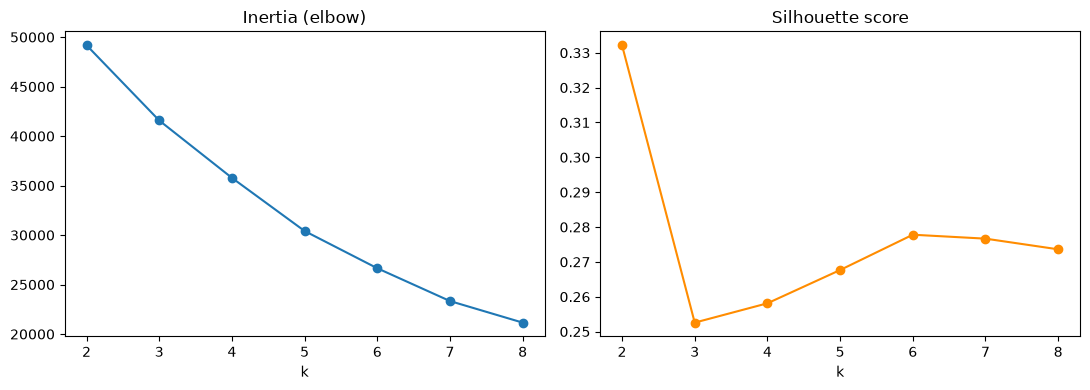

,k,inertia,silhouette,min_cluster_size
0,2,49181.362714,0.332170,2513
1,3,41576.467442,0.252572,1021
2,4,35780.829945,0.258120,921
3,5,30411.250303,0.267664,90
4,6,26648.472245,0.277796,29
5,7,23335.489064,0.276665,29
6,8,21157.326386,0.273605,29


In [2]:
X_scaled, scale_pipeline = prepare_matrix(fm)
k_results = select_k(X_scaled, k_range=range(2, 9))
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(k_results['k'], k_results['inertia'], marker='o')
axes[0].set_title('Inertia (elbow)')
axes[0].set_xlabel('k')
axes[1].plot(k_results['k'], k_results['silhouette'], marker='o', color='darkorange')
axes[1].set_title('Silhouette score')
axes[1].set_xlabel('k')
plt.tight_layout()
plt.show()
k_results

**Silhouette peaks at k=2** — but that split turns out to be a near-trivial "engaged vs. not" cut (checked below), not useful for differentiated retention treatment. k=5+ starts producing an unbalanced tiny cluster (`min_cluster_size` drops to 90, then 29). **k=4** is where inertia's elbow flattens while every cluster stays large enough to act on — the choice here prioritizes business usability over the single highest silhouette score, and that trade-off is stated explicitly rather than silently picking the top silhouette row.

In [3]:
k = 4
kmeans = fit_kmeans(X_scaled, k=k)
fm_clustered = fm.copy()
fm_clustered['cluster'] = kmeans.labels_
profile = profile_clusters(fm_clustered, churn_labels=churn, clv_labels=clv)
profile.round(2)

,size,recency_days,frequency,monetary,engagement_ratio,category_breadth,tenure_days,churned,future_clv
cluster,,,,,,,,,
0,921,10.66,43.79,2209.98,1.18,7.77,529.35,0.04,644.29
3,2649,62.31,20.11,986.22,0.95,7.03,532.13,0.28,256.18
2,2365,363.54,5.01,242.80,0.02,3.21,597.29,0.75,36.11
1,2065,70.36,4.52,214.60,2.87,2.99,293.69,0.36,181.17


## PCA projection (visualization only — clustering ran on the full feature set, not these 2 components)

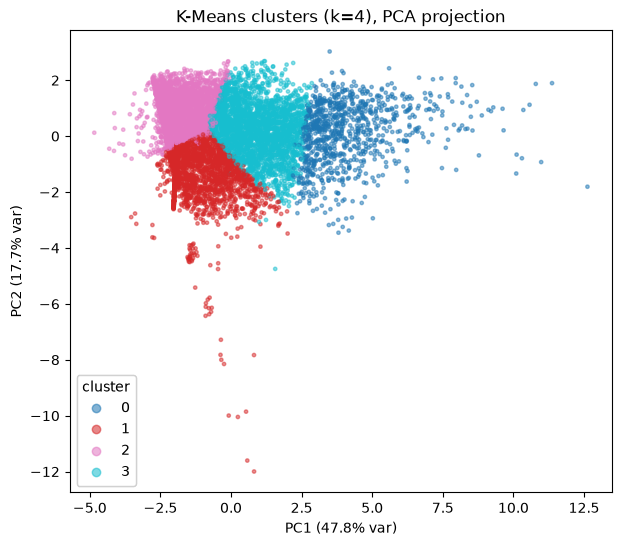

first 2 PCs explain 65.5% of variance


In [4]:
coords, pca = pca_projection(X_scaled, n_components=2)
fig, ax = plt.subplots(figsize=(7, 6))
scatter = ax.scatter(coords[:, 0], coords[:, 1], c=kmeans.labels_, cmap='tab10', s=6, alpha=0.5)
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} var)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} var)')
ax.set_title('K-Means clusters (k=4), PCA projection')
legend = ax.legend(*scatter.legend_elements(), title='cluster')
ax.add_artist(legend)
plt.show()
print(f'first 2 PCs explain {pca.explained_variance_ratio_[:2].sum():.1%} of variance')

## Hierarchical clustering — a sanity check, not the production method

Understanding an alternative algorithm matters even when it isn't the one shipped: agreement with K-Means (measured, not eyeballed) tells us whether the k=4 structure is a real feature of the data or an artifact of K-Means' spherical-cluster bias.

In [5]:
from sklearn.metrics import adjusted_rand_score

hier_labels = fit_hierarchical(X_scaled, k=4)
ari = adjusted_rand_score(kmeans.labels_, hier_labels)
print('Adjusted Rand Index (K-Means vs. hierarchical, k=4):', round(ari, 3))
pd.crosstab(kmeans.labels_, hier_labels, rownames=['kmeans'], colnames=['hierarchical'])

Adjusted Rand Index (K-Means vs. hierarchical, k=4): 0.572


hierarchical,0,1,2,3
kmeans,,,,
0,0,205,716,0
1,1711,222,0,132
2,393,9,0,1963
3,94,2181,9,365


Moderate agreement (ARI 0.57, where 0 is random and 1 is identical) is the expected outcome here: the two algorithms broadly agree on the big divisions (dormant vs. active) but draw the boundary between adjacent segments (e.g. "steady" vs. "new") differently, which is normal given they optimize different objectives (K-Means: within-cluster variance; hierarchical: linkage distance). It is high enough to say the k=4 structure reflects something real in the data, not an artifact of K-Means alone.

## Naming the segments — from the profile, not before it

Based on the cluster-profile table above:

In [6]:
from segmentation.cluster import name_segments_from_profile

names = name_segments_from_profile(profile)
named_profile = profile.rename(index=names)
named_profile.round(2)

,size,recency_days,frequency,monetary,engagement_ratio,category_breadth,tenure_days,churned,future_clv
cluster,,,,,,,,,
Champions,921,10.66,43.79,2209.98,1.18,7.77,529.35,0.04,644.29
Steady Regulars,2649,62.31,20.11,986.22,0.95,7.03,532.13,0.28,256.18
Dormant / Lost,2365,363.54,5.01,242.80,0.02,3.21,597.29,0.75,36.11
New / Developing,2065,70.36,4.52,214.60,2.87,2.99,293.69,0.36,181.17


## Takeaway

Four segments with clearly different retention economics: Champions (lowest churn, highest CLV — protect, don't discount), Steady Regulars (moderate on both — the volume base), New/Developing (short tenure, still forming habits — needs onboarding, not a churn intervention), Dormant/Lost (already gone in practice — a win-back campaign, not a retention one, is the right lever). Full numbers in `docs/segmentation_report.md`.